# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [64]:
import pandas as pd

In [65]:
df = pd.read_csv('tweet_sentiment_train.csv.zip', index_col='textID')
df.head()

,text,selected_text,sentiment
textID,,,
cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
088c60f138,my boss is bullying me...,bullying me,negative
9642c003ef,what interview! leave me alone,leave me alone,negative
358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27481 entries, cb774db0d1 to 6f7127d9d7
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           27480 non-null  object
 1   selected_text  27480 non-null  object
 2   sentiment      27481 non-null  object
dtypes: object(3)
memory usage: 858.8+ KB


In [67]:
df = df.dropna()

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [68]:
df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
length = [len(i) for i in df.text]

<function tuple.index(value, start=0, stop=9223372036854775807, /)>

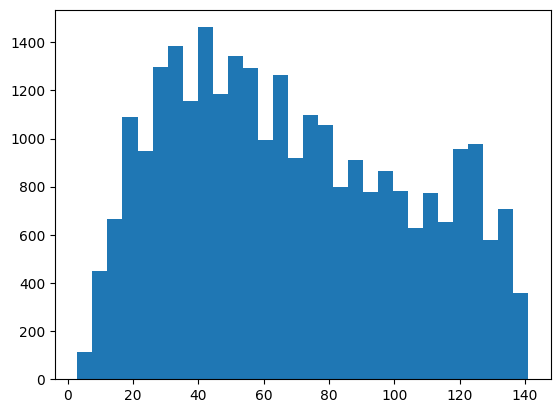

In [71]:
plt.hist(length, bins = 30).index

In [72]:
df['length'] = length

In [73]:
df.length.mode()

,length
0,41


In [74]:
df.groupby(df.sentiment).length.value_counts().sort_values(ascending=False).groupby(level=0).head(1)

,,count
sentiment,length,
neutral,28,137
positive,45,108
negative,48,96


In [75]:
df.describe()

,length
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


<Axes: xlabel='length'>

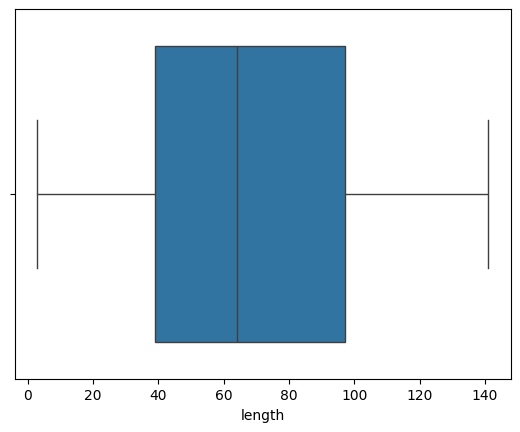

In [76]:
sns.boxplot(data=df, x='length')

Найбільше довжин постів = 41 символи. По категорім видно, що neutral пости частіше за все коротші за емоційно забарвлені.

Загальний розподіл довжин - наближений до нормального.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [77]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [78]:
# етап 1 - токенизація по словам

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [79]:
from nltk.tokenize import word_tokenize

In [80]:
df['tokens'] = [word_tokenize(text.lower(), language='english') for text in df['text']]

In [81]:
# подивитися на прикладі - як спрацювало

def check_process(a):
  print(df.text.iloc[a])
  print(df.tokens.iloc[a])

check_process(100)

4am. And Im on the beach. Pretty
['4am', '.', 'and', 'im', 'on', 'the', 'beach', '.', 'pretty']


In [82]:
# етап 2 - видалення стоп-слів зі створених списків токенів

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [83]:
english_stopwords = stopwords.words('english')

In [84]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in english_stopwords]

In [85]:
df['tokens_filtered'] =  df['tokens'].apply(remove_stopwords)

In [86]:
a = 100
check_process(a)
print(df['tokens_filtered'].iloc[a])

4am. And Im on the beach. Pretty
['4am', '.', 'and', 'im', 'on', 'the', 'beach', '.', 'pretty']
['4am', '.', 'im', 'beach', '.', 'pretty']


In [87]:
# етап 3 - виконання обрізання закінчень з SnowballStemmer

from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer(language='english')

In [88]:
def stemming(tokens_filtered):
    return [stemmer.stem(word) for word in tokens_filtered]

In [89]:
df['tokens_filtered_stemmed'] =  df['tokens_filtered'].apply(stemming)

In [90]:
a = 66
check_process(a)
print(df['tokens_filtered'].iloc[a])
print(df['tokens_filtered_stemmed'].iloc[a])

  He`s awesome... Have you worked with him before? He`s a good friend.
['he', '`', 's', 'awesome', '...', 'have', 'you', 'worked', 'with', 'him', 'before', '?', 'he', '`', 's', 'a', 'good', 'friend', '.']
['`', 'awesome', '...', 'worked', '?', '`', 'good', 'friend', '.']
['`', 'awesom', '...', 'work', '?', '`', 'good', 'friend', '.']


In [91]:
# етап 4 - створення словнику

from sklearn.feature_extraction.text import CountVectorizer

In [92]:
vectorizer = CountVectorizer(
    max_df=0.96,
    min_df=0.02,
    max_features=75,
    lowercase=False,
    )

text_series = df['tokens_filtered_stemmed'].apply(lambda tokens: ' '.join(tokens))
X = vectorizer.fit_transform(text_series)

feature_names = vectorizer.get_feature_names_out()

inputs = pd.DataFrame(X.toarray(), columns=feature_names)
inputs

,back,com,come,day,feel,get,go,good,got,great,...,thank,think,time,today,twitter,want,watch,well,wish,work
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27475,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
27476,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27477,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
27478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [93]:
df['sentiment_encoded'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

In [94]:
from sklearn.model_selection import train_test_split

In [95]:
y = df.sentiment_encoded
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    inputs,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y,
    )

In [96]:
X_train_bow.shape

(23358, 45)

In [97]:
X_test_bow.shape

(4122, 45)

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score

In [99]:
log_reg = LogisticRegression(max_iter=1000)
ovr_model = OneVsRestClassifier(log_reg)
ovr_model.fit(X_train_bow, y_train)
ovr_predictions_bow = ovr_model.predict(X_test_bow)

In [100]:
# оцінюватиму якість за f1_macro_score для усередненої оцінки по класам, не какцентуючись на precision або recall

print(round(f1_score(y_test, ovr_predictions_bow, average='macro'), 3))

0.503


In [101]:
from sklearn.tree import DecisionTreeClassifier

In [102]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train_bow, y_train)
    train_error = 1 - model.score(X_train_bow, y_train)
    test_error = 1 - model.score(X_test_bow, y_test)
    return {'Max Depth': md, 'Training Error': train_error, 'Test Error': test_error}

errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])
print(errors_df.sort_values('Test Error').head(1))

   Max Depth  Training Error  Test Error
7          8        0.449097    0.457545


In [103]:
def max_leafs_error(ml):
    model = DecisionTreeClassifier(max_leaf_nodes=ml, random_state=42)
    model.fit(X_train_bow, y_train)
    train_error = 1 - model.score(X_train_bow, y_train)
    test_error = 1 - model.score(X_test_bow, y_test)
    return {'Max Leaf Nodes': ml, 'Training Error': train_error, 'Test Error': test_error}

errors_df = pd.DataFrame([max_leafs_error(ml) for ml in range(2, 30)])
print(errors_df.sort_values('Test Error').head(1))

    Max Leaf Nodes  Training Error  Test Error
15              17        0.447984    0.453906


In [104]:
dst_model = DecisionTreeClassifier(max_depth=9, max_leaf_nodes=23, random_state=42)
dst_model.fit(X_train_bow, y_train)
dst_predictions = dst_model.predict(X_test_bow)

In [105]:
print(f1_score(y_test, dst_predictions, average='macro'))

0.48158659641434953


In [106]:
from sklearn.neighbors import KNeighborsClassifier

In [107]:
knn_model = KNeighborsClassifier(n_neighbors=78)
knn_model.fit(X_train_bow, y_train)
knn_predictions = knn_model.predict(X_test_bow)
print(f1_score(y_test, knn_predictions, average='macro'))

0.48810562367181376


За показником f1_macro_score лінійна регресія виявилася найвдалішею (=0.503). Загалом показник доволі невисокий, потрібно точно оптимізовувати.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [108]:
coefficients_bow = [est.coef_[0] for est in ovr_model.estimators_]

feature_importance_0_bow = pd.Series(coefficients_bow[0], index=feature_names, name='imp').sort_values(ascending=False).round(3)
feature_importance_0_bow

,imp
miss,1.727
feel,1.135
im,0.503
realli,0.416
oh,0.404
much,0.358
still,0.273
na,0.261
work,0.206
get,0.159


Якщо аналізувати вплив слів(токенів) на визначення негативного сентименту, то є ті значення з якими не погоджуюсь (пр. im, realli, oh, still...). Потрібно розглядати кожен випадок окремо

In [109]:
df['prediction_bow'] = ovr_model.predict(inputs)
df['prediction_proba_Neg'], df['prediction_proba_Neu'], df['prediction_proba_Pos'] = ovr_model.predict_proba(inputs).T[0].round(3), ovr_model.predict_proba(inputs).T[1].round(3), ovr_model.predict_proba(inputs).T[2].round(3)

In [110]:
df['error_bow'] = df.sentiment_encoded != df['prediction_bow']

In [111]:
feature_names

array(['back', 'com', 'come', 'day', 'feel', 'get', 'go', 'good', 'got',
       'great', 'happi', 'home', 'hope', 'http', 'im', 'know', 'last',
       'like', 'lol', 'look', 'love', 'make', 'miss', 'morn', 'mother',
       'much', 'na', 'need', 'new', 'night', 'oh', 'one', 'realli', 'see',
       'still', 'thank', 'think', 'time', 'today', 'twitter', 'want',
       'watch', 'well', 'wish', 'work'], dtype=object)

In [112]:
df[(df.error_bow!=0) & (df.sentiment_encoded==0)][['text', 'sentiment_encoded',
                                               'prediction_bow', 'prediction_proba_Neg', 'prediction_proba_Neu', 'prediction_proba_Pos']].tail()

,text,sentiment_encoded,prediction_bow,prediction_proba_Neg,prediction_proba_Neu,prediction_proba_Pos
textID,,,,,,
d32efe060f,i wanna leave work already! Not feelin it 2day,0,1,0.419,0.469,0.112
778184dff1,lol i know and haha..did you fall asleep?? o...,0,1,0.200,0.625,0.175
8f5adc47ec,http://twitpic.com/663vr - Wanted to visit the...,0,1,0.217,0.582,0.201
4eac33d1c0,wish we could come see u on Denver husband l...,0,2,0.154,0.315,0.531
4f4c4fc327,I`ve wondered about rake to. The client has ...,0,1,0.246,0.481,0.273


Трохи проаналізувавши false positive\neutral, я в багатьох випадках можу розпізнати тон по тим словам, які взагалі не увійшли в словник. Можливо були задані занадто жорсткі обмеження для його створення і можна спробувати їх послабити і подивитися чи покращиться якість моделі.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [114]:
vectorizer = TfidfVectorizer(
    max_df=0.96,
    min_df=0.02,
    max_features=75,
    lowercase=False,
)
tfidf_matrix = vectorizer.fit_transform(text_series)

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names).round(3)
tfidf_df

,back,com,come,day,feel,get,go,good,got,great,...,thank,think,time,today,twitter,want,watch,well,wish,work
0,0.0,0.0,0.000,0.0,0.0,0.0,1.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
1,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
2,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
3,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
4,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27475,0.0,0.0,0.592,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.591,0.0
27476,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
27477,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.639,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
27478,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0


In [115]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_df,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y,
    )

In [116]:
lr_f1_score_bow = round(f1_score(y_test, ovr_predictions_bow, average='macro'), 3)

In [117]:
ovr_model.fit(X_train_tfidf, y_train)
ovr_predictions_tfidf = ovr_model.predict(X_test_tfidf)
lr_f1_score_tfidf = round(f1_score(y_test, ovr_predictions_tfidf, average='macro'), 3)

print('BOW F1 score:', lr_f1_score_bow)
print('TF-IDF F1 score:', lr_f1_score_tfidf)

BOW F1 score: 0.503
TF-IDF F1 score: 0.509


Якість моделі покращилась, але не на багато

In [118]:
coefficients_tfidf = [est.coef_[0] for est in ovr_model.estimators_]

feature_importance_0_tfidf = pd.Series(coefficients_tfidf[0], index=feature_names, name='imp_tfidf').sort_values(ascending=False).round(3)


In [119]:
df_compare = pd.DataFrame({'BOW': feature_importance_0_bow, 'TF-IDF': feature_importance_0_tfidf})
df_compare['Is_Equal'] = df_compare['BOW'] == df_compare['TF-IDF']
display(df_compare.sort_values('TF-IDF', ascending=False))

,BOW,TF-IDF,Is_Equal
miss,1.727,2.423,False
feel,1.135,1.672,False
im,0.503,0.792,False
realli,0.416,0.658,False
oh,0.404,0.616,False
much,0.358,0.527,False
na,0.261,0.419,False
still,0.273,0.380,False
work,0.206,0.327,False
get,0.159,0.247,False


Обидва методи дали досить схожі посередні результати. Принаймні з тими гіперпараметрами, які були задані, для фінальнох імплементації рішення я б не використала жоден з методів векторизації. Подумала б більше про TF-IDF з іншими параметрами, якщо стояв би вибір, оскільки для цього методу робиться більш складний аналіз, і має більше потенціалу для покращення.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [120]:
df['prediction_tfidf'] = ovr_model.predict(tfidf_df)
df['error_tfidf'] = df.sentiment_encoded != df['prediction_tfidf']

In [121]:
df[(df.error_tfidf!=0) & (df.sentiment_encoded==0)][['text', 'sentiment_encoded', 'prediction_tfidf']].tail()

,text,sentiment_encoded,prediction_tfidf
textID,,,
d32efe060f,i wanna leave work already! Not feelin it 2day,0,1
778184dff1,lol i know and haha..did you fall asleep?? o...,0,1
8f5adc47ec,http://twitpic.com/663vr - Wanted to visit the...,0,1
4eac33d1c0,wish we could come see u on Denver husband l...,0,2
4f4c4fc327,I`ve wondered about rake to. The client has ...,0,1


Для покращення можна:

*   Зробити менше обмежень при створенні словника (понизити знячення гіперпараметрів min_df), щоб розширити його і дати можливість моделі опиратися на більше даних
*   Спробувати додати гіперпараметр sublinear_tf до векторизатора, і таким чином знизити вплив занадто повторюваних слів
*   Налаштувати всю обробку у векторизаторі, а не робити окремий препроцесинг як перший етап


І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model